만유인력 식 물리 상수는 1로 가정

In [232]:

import numpy as np
import pandas as pd

def generate_data(noise_strength=0.1):
    """
    만유인력 공식 기반 데이터를 생성하고 가우시안 노이즈를 추가합니다.
    """
    np.random.seed(42)
  
    m1 = np.random.uniform(1, 10, 200)
    m2 = np.random.uniform(1, 10, 200)
    r = np.random.uniform(1, 5, 200)
    
    # 1. 순수 만유인력 공식 계산 (Y = m1 * m2 / r^2)
    Y_pure = (m1 * m2) / (r ** 2)
    
    # 2. 가우시안 노이즈 추가
    noise = np.random.normal(0, noise_strength, size=200)
    Y_noisy = Y_pure + noise
    
    # 3. 딕셔너리 리스트 구조로 조립
    dataset_records = []
    for i in range(200):
        row = {
            'X0': m1[i],
            'X1': m2[i],
            'X2': r[i],
            'Y': Y_noisy[i]
        }
        dataset_records.append(row)
        
    return dataset_records

# ==========================================
# 데이터 생성 및 메인 루프 변수명 일치화
# ==========================================
data_records = generate_data(noise_strength=2.0) #노이즈 강도 조절
df = pd.DataFrame(data_records)

# 💡 메인 루프에서 사용하는 이름인 X_train, y_train으로 아예 고정합니다!
X_train = df[['X0', 'X1', 'X2']].values 
y_train = df['Y'].values     

# CSV 파일 저장
df.to_csv('my_data.csv', index=False) 

print("✅ X_train, y_train 변수 선언 완료! 이제 메인 루프를 그냥 실행하시면 됩니다.")


✅ X_train, y_train 변수 선언 완료! 이제 메인 루프를 그냥 실행하시면 됩니다.


유체 항력  전환 기준: 레이놀즈 수 Re = ρvd/μ
-저속(층류, Stokes 영역): F = 6πμrv
-고속(난류, 뉴턴 영역): F = ½ρCdAv²

In [233]:
def generate_drag_force_data(n_samples=200, noise_strength=0.5, re_threshold=1.0, random_seed=42):
    np.random.seed(random_seed)

    v   = np.random.uniform(0.1, 5.0, n_samples)
    r   = np.random.uniform(0.1, 2.0, n_samples)
    rho = np.random.uniform(0.5, 3.0, n_samples)
    mu  = np.random.uniform(0.5, 2.0, n_samples)
    Cd  = np.random.uniform(0.3, 1.2, n_samples)

    Re = 2 * rho * v * r / mu
    logRe = np.log(Re)

    F_stokes = 6 * np.pi * mu * r * v
    F_newton = 0.5 * Cd * rho * (r ** 2) * (v ** 2)

    is_laminar = Re < re_threshold
    F_pure = np.where(is_laminar, F_stokes, F_newton)

    noise = np.random.normal(0, noise_strength, size=n_samples)
    F_noisy = F_pure + noise

    regime = np.where(is_laminar, "laminar(Stokes)", "turbulent(Newton)")

    records = []
    for i in range(n_samples):
        records.append({
            'X0': v[i], 'X1': r[i], 'X2': rho[i], 'X3': mu[i], 'X4': Cd[i],
            'Y': F_noisy[i], 'Re': Re[i], 'logRe': logRe[i], 'regime': regime[i]
        })
    return records


data_records = generate_drag_force_data(n_samples=500, noise_strength=0.5, re_threshold=1.0)
df = pd.DataFrame(data_records)

print(df['regime'].value_counts())
print(df.groupby('regime')['Re'].describe())

df.to_csv('drag_force_data.csv', index=False)

regime
turbulent(Newton)    434
laminar(Stokes)       66
Name: count, dtype: int64
                   count      mean        std       min      25%       50%  \
regime                                                                       
laminar(Stokes)     66.0  0.529541   0.285695  0.081765  0.28293  0.541309   
turbulent(Newton)  434.0  9.966726  10.320244  1.002071  3.04590  6.620765   

                         75%        max  
regime                                   
laminar(Stokes)     0.768133   0.981925  
turbulent(Newton)  13.939248  85.277528  


기체 방정식 기체 상수는 1로 가정

In [234]:
''''
import random
import numpy as np
import pandas as pd


num_samples = 100
data_list = []

for _ in range(num_samples):
    X0 = random.uniform(1.0, 5.0)       # 압력
    x1 = random.uniform(10.0, 30.0)     # 부피
    x2 = random.uniform(273.15, 373.15) # 온도
    
  
    actual_y = (X0 * x1) / x2
    
    data_list.append({'X0': X0, 'x1': x1, 'x2': x2, 'Y': actual_y})

data = data_list

#  gplearn / pySR용 틀 (Pandas DataFrame)
df = pd.DataFrame(data)
X_matrix = df[['X0', 'x1', 'x2']].values 
y_vector = df['Y'].values     

df.to_csv('my_data.csv', index=False) #index = false -> 번호칸 제외 변수와 데이터만 저장
data = generate_data()
data.to_csv('my_data.csv', index=False)

'''

"'\nimport random\nimport numpy as np\nimport pandas as pd\n\n\nnum_samples = 100\ndata_list = []\n\nfor _ in range(num_samples):\n    X0 = random.uniform(1.0, 5.0)       # 압력\n    x1 = random.uniform(10.0, 30.0)     # 부피\n    x2 = random.uniform(273.15, 373.15) # 온도\n\n\n    actual_y = (X0 * x1) / x2\n\n    data_list.append({'X0': X0, 'x1': x1, 'x2': x2, 'Y': actual_y})\n\ndata = data_list\n\n#  gplearn / pySR용 틀 (Pandas DataFrame)\ndf = pd.DataFrame(data)\nX_matrix = df[['X0', 'x1', 'x2']].values \ny_vector = df['Y'].values     \n\ndf.to_csv('my_data.csv', index=False) #index = false -> 번호칸 제외 변수와 데이터만 저장\ndata = generate_data()\ndata.to_csv('my_data.csv', index=False)\n\n"

PySR


Decision Tree

 라이브러리 import (전체 통합)

In [266]:


# ---------- 표준 라이브러리 ----------
import sys
import random
import re
import copy   # ⚠️ 위쪽 소문자 Node/population 프로토타입(crossover, mutation)에서만 사용됨
import math   # ⚠️ 위쪽 소문자 Node/population 프로토타입(evaluate_fitness)에서만 사용됨

# ---------- 수치 계산 / 데이터 처리 ----------
import numpy as np
import pandas as pd

# ---------- 시각화 ----------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Decision Tree 구간 분할 ----------
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

# ---------- 심볼릭 수식 단순화 ----------
import sympy as sp

# ---------- 상수 최적화 ----------
from scipy.optimize import minimize

# ---------- PySR / Julia 백엔드 ----------
# 최초 1회만 필요 (이미 설치돼 있다면 이 줄은 주석 처리해도 됨)
# !{sys.executable} -m pip install pysr

import pysr
pysr.install()          # 이미 설치돼 있으면 빠르게 스킵됨

from pysr import jl

# ---------- 한글 깨짐 방지 (시각화용) ----------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

c:\Users\songa\AppData\Local\Programs\Python\Python313\Lib\site-packages\pysr\deprecated.py:10: FutureWarning: The `install` function has been removed. PySR now uses the `juliacall` package to install its dependencies automatically at import time. 
  warnings.warn(


데이터셋 설정

In [267]:
FILE_PATH = 'drag_force_data.csv'
FEATURES = [ 'logRe'] 
TARGET = 'Y'                 
SPLIT_TARGET = 'regime' 

N_GROUPS = 2      
MIN_SAMPLES_LEAF = 40  



In [268]:
# %%
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree  # Regressor → Classifier

class TreeSpliter:
    def __init__(self, file_path, feature_cols, target_col, split_target_col):
        self.df = pd.read_csv(file_path)
        self.feature_cols = feature_cols
        self.target_col = target_col            # SR용 ('Y')
        self.split_target_col = split_target_col # 분기용 ('regime')
        self.tree = None
        self.grouped_datasets = []

    def fit_and_split(self, n_groups, min_samples_leaf):
        X = self.df[self.feature_cols]
        y = self.df[self.split_target_col]   # 트리 학습은 regime으로!
     
        self.tree = DecisionTreeClassifier(
            max_leaf_nodes=n_groups, 
            min_samples_leaf=min_samples_leaf, 
            random_state=42
        )
        self.tree.fit(X, y)
        
        print("decision tree 분기 기준")
        print(export_text(self.tree, feature_names=self.feature_cols))
        
        self.df['group_id'] = self.tree.apply(X)
        
        self.grouped_datasets = []
        print("그룹 분할 결과")
        for g_id in sorted(self.df['group_id'].unique()):
            group_df = self.df[self.df['group_id'] == g_id]
            X_group = group_df[['X0', 'X1', 'X2', 'X3', 'X4']]   # SR용: Re/logRe/regime 제외
            y_group = group_df[self.target_col]                  # SR용: 'Y'
            
            self.grouped_datasets.append((X_group, y_group, g_id))
            print(f"Group {g_id} 분리 완료 (샘플 수 {len(group_df)}개)")
            
        return self.grouped_datasets

    def visualize(self):
        if self.tree is None:
            raise ValueError("먼저 fit_and_split() 메소드를 실행하여 모델을 학습")
            
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        plot_tree(
            self.tree, 
            feature_names=self.feature_cols, 
            filled=True, 
            rounded=True, 
            ax=axes[0],
            fontsize=10
        )
        axes[0].set_title("의사결정 나무 분기 구조", fontsize=14, fontweight='bold')
        
        importances = self.tree.feature_importances_
        best_feature_idx = importances.argmax()
        best_feature_name = self.feature_cols[best_feature_idx]
        
        sns.scatterplot(
            data=self.df, 
            x=best_feature_name, 
            y=self.target_col,   # 'Y'
            hue='group_id', 
            palette='Set1', 
            alpha=0.8, 
            ax=axes[1]
        )
        
        thresholds = [t for t in self.tree.tree_.threshold if t != -2]
        for val in thresholds:
            axes[1].axvline(x=val, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
            
        axes[1].set_title(f"{best_feature_name} 기준 그룹 분포", fontsize=14, fontweight='bold')
        axes[1].set_xlabel(f"{best_feature_name} 값", fontsize=12)
        axes[1].set_ylabel(self.target_col, fontsize=12)
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()

# %%

decision tree 분기 기준
|--- logRe <= -0.01
|   |--- class: laminar(Stokes)
|--- logRe >  -0.01
|   |--- class: turbulent(Newton)

그룹 분할 결과
Group 1 분리 완료 (샘플 수 66개)
Group 2 분리 완료 (샘플 수 434개)


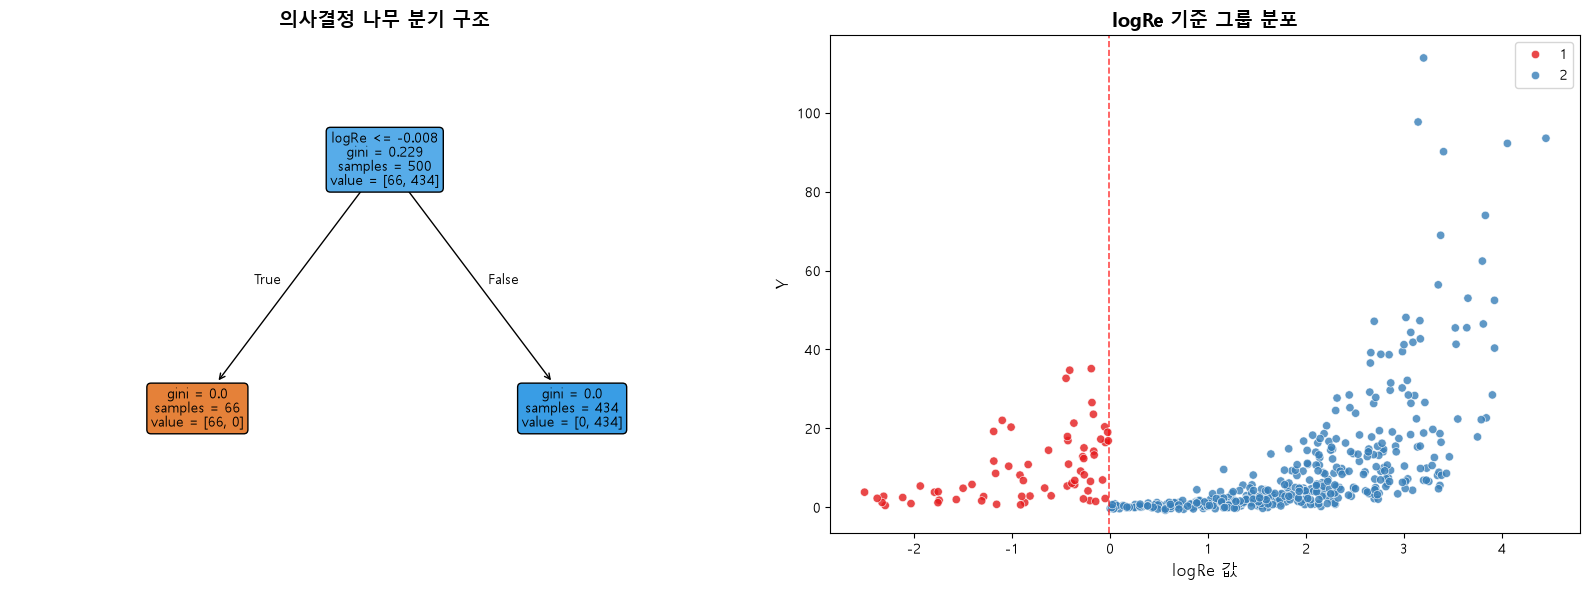

In [269]:
splitter = TreeSpliter(
    file_path=FILE_PATH, 
    feature_cols=FEATURES, 
    target_col=TARGET,              # 'Y'
    split_target_col=SPLIT_TARGET   # 'regime'
)
grouped_data = splitter.fit_and_split(n_groups=N_GROUPS, min_samples_leaf=MIN_SAMPLES_LEAF)
splitter.visualize()

In [270]:
for g_id in sorted(splitter.df['group_id'].unique()):
    subset = splitter.df[splitter.df['group_id'] == g_id]
    print(f"[Group {g_id}]  샘플수={len(subset)}")
    print(subset['regime'].value_counts())
    print(f"  Re 범위: {subset['Re'].min():.3f} ~ {subset['Re'].max():.3f}")
    print()

[Group 1]  샘플수=66
regime
laminar(Stokes)    66
Name: count, dtype: int64
  Re 범위: 0.082 ~ 0.982

[Group 2]  샘플수=434
regime
turbulent(Newton)    434
Name: count, dtype: int64
  Re 범위: 1.002 ~ 85.278



In [271]:
check_df = pd.read_csv('drag_force_data.csv')
print(check_df[['Re', 'logRe', 'regime']].sort_values('Re').head(10))
print(check_df[['Re', 'logRe', 'regime']].sort_values('Re').iloc[60:75])  # Re=1 근처 확인

           Re     logRe           regime
72   0.081765 -2.503911  laminar(Stokes)
374  0.093030 -2.374833  laminar(Stokes)
332  0.097771 -2.325130  laminar(Stokes)
201  0.099386 -2.308743  laminar(Stokes)
128  0.100998 -2.292655  laminar(Stokes)
208  0.120713 -2.114336  laminar(Stokes)
356  0.131325 -2.030083  laminar(Stokes)
164  0.144376 -1.935332  laminar(Stokes)
99   0.166839 -1.790726  laminar(Stokes)
436  0.172934 -1.754846  laminar(Stokes)
           Re     logRe             regime
90   0.926688 -0.076138    laminar(Stokes)
28   0.947008 -0.054447    laminar(Stokes)
497  0.951652 -0.049556    laminar(Stokes)
58   0.953484 -0.047633    laminar(Stokes)
66   0.976448 -0.023834    laminar(Stokes)
285  0.981925 -0.018240    laminar(Stokes)
37   1.002071  0.002069  turbulent(Newton)
387  1.018592  0.018422  turbulent(Newton)
426  1.024354  0.024062  turbulent(Newton)
321  1.032775  0.032250  turbulent(Newton)
339  1.038938  0.038199  turbulent(Newton)
264  1.050975  0.049718  turbulen

In [272]:
for X_g, y_g, gid in grouped_data:
    print(gid, X_g.columns.tolist(), len(X_g))

1 ['X0', 'X1', 'X2', 'X3', 'X4'] 66
2 ['X0', 'X1', 'X2', 'X3', 'X4'] 434


PySR 초기 설정

연산자 설정

In [273]:
TERMINAL_SET = ['X0', 'X1', 'X2', 'X3', 'X4'] 

#function_Set
BINARY_OPERATORS = ["*", "/"] #이항 연산자
UNARY_OPERATORS  = ["square"] #단항 연산자

#다중 population을 위한 설정 
NUM_POPULATIONS = 15  #migration 주고 받을 섬의 개수
POPULATION_SIZE = 100 #섬 하나당 들어갈 수식의 개수 -> 총 population 수는 8*100

MAX_ITERATIONS = 100 #전체 학습의 사이클 수
MAX_COMPLEXITY = 10 #복잡도 제한 (연산자+변수의 총 개수 제한)

MAX_DEPTH = 6
TARGET_FITNESS = 0.0

MONOTONICITY_CONSTRAINTS = [1,1,1,1,1]

# Options(binary_operators=[+,-,*,/])의 순서와 정확히 일치해야 함
BINARY_OP_INDEX = {'*': 3, '/': 4}  #'+': 1, '-': 2,
# Options(unary_operators=[square,sqrt,log,exp])의 순서와 정확히 일치해야 함
UNARY_OP_INDEX = {'square': 1 } #'sqrt': 2, 'log': 3, 'exp': 4

PARSIMONY = 0.001   # 값이 클수록 "짧고 간단한 수식"을 더 선호

노드 클래스 정의 - Node 역할 구분 , 계산기, 복잡도 제어

In [274]:
#NODE_TYPE: 'VARIABLE' (변수), 'CONSTANT' (상수), 'BINARY' (이항연산), 'UNARY' (단항연산)
#VALUE: '+', 'X0', 1.5 등 실제 노드가 가지는 값
#CHILDREN: 자식 노드들의 리스트
#-> 'CONSTANT' 상수 최적화(미세 조정)을 위해 NODE_TYPE을 기재

class NODE:
    def __init__(self, NODE_TYPE, VALUE=None, CHILDREN=None):
        self.NODE_TYPE = NODE_TYPE
        self.VALUE = VALUE
        self.CHILDREN = CHILDREN if CHILDREN is not None else []


    def EVALUATE(self, X):
       
    #입력 데이터 X를 받아 이 수식 트리 전체를 재귀적으로 계산하여 결과를 반환.
       
        # (1) 변수 노드인 경우: 해당 열(Feature) 데이터를 반환
        if self.NODE_TYPE == 'VARIABLE':
            IDX = int(self.VALUE[1:])  # 'X0' -> 0, 'X1' -> 1 추출
            return X[:, IDX]
        
        # (2) 상수 노드인 경우: 데이터 행 개수만큼의 크기를 가진 상수 배열 반환
        elif self.NODE_TYPE == 'CONSTANT':
            return np.full(X.shape[0], self.VALUE)
        
        # (3) 단항 연산자 노드인 경우: 자식이 1개이므로 첫 번째 자식만 계산 후 연산 적용
        elif self.NODE_TYPE == 'UNARY':
            CHILD_VAL = self.CHILDREN[0].EVALUATE(X)
            if self.VALUE == 'square': 
                return np.square(CHILD_VAL)
            elif self.VALUE == 'sqrt': 
                return np.sqrt(np.abs(CHILD_VAL))
            elif self.VALUE == 'log':
                # 0 또는 음수 입력 시 발산 방지
                return np.log(np.abs(CHILD_VAL) + 1e-9)
            elif self.VALUE == 'exp':
                # 오버플로우 방지를 위한 임계값 클리핑
                return np.exp(np.clip(CHILD_VAL, -20, 20))
        
        # (4) 이항 연산자 노드인 경우: 왼쪽, 오른쪽 자식을 각각 계산 후 연산 적용
        elif self.NODE_TYPE == 'BINARY':
            LEFT = self.CHILDREN[0].EVALUATE(X)
            RIGHT = self.CHILDREN[1].EVALUATE(X)
            if self.VALUE == '+': return LEFT + RIGHT
            if self.VALUE == '-': return LEFT - RIGHT
            if self.VALUE == '*': return LEFT * RIGHT
            if self.VALUE == '/': 
                # 분모가 0이 되는 것을 방지 
                return np.divide(LEFT, RIGHT, out=np.zeros_like(LEFT), where=RIGHT!=0)
            
        return np.zeros(X.shape[0])

    def GET_COMPLEXITY(self):
        
        #수식의 총 복잡도(총 노드 개수)를 계산
        # 자기 자신(1) + 모든 자식 노드들의 복잡도 합
        return 1 + sum(CHILD.GET_COMPLEXITY() for CHILD in self.CHILDREN)

    def COPY(self): #복사(Deep Copy)하는 함수 , 원본트리가 망가지는 것을 방지
        
        return NODE(self.NODE_TYPE, self.VALUE, [CHILD.COPY() for CHILD in self.CHILDREN])

무작위 수식 트리 생성 함수

In [275]:
def GENERATE_RANDOM_TREE(DEPTH, TERMINAL_SET, BINARY_OPS, UNARY_OPS):
   
    # (1) 최대 깊이에 도달했거나 무작위 확률(30%)에 걸리면 Terminal 노드 생성
    if DEPTH == 0 or random.random() < 0.3:
        if random.random() < 0.5:
            # 변수 노드 선택
            return NODE('VARIABLE', VALUE=random.choice(TERMINAL_SET))
        else:
            # 상수 노드 선택 (-5.0 ~ 5.0 사이의 무작위 실수 생성)
            #  처음에 무작위 상수 넣고 나중에 미세 조정
            return NODE('CONSTANT', VALUE=random.uniform(-5.0, 5.0))
    
    # (2) 연산자 노드 생성 (이항 연산 60%, 단항 연산 40% 확률로 분기)
    if random.random() < 0.6:
        OP = random.choice(BINARY_OPS)
        # 이항 연산자
        LEFT_CHILD  = GENERATE_RANDOM_TREE(DEPTH - 1, TERMINAL_SET, BINARY_OPS, UNARY_OPS)
        RIGHT_CHILD = GENERATE_RANDOM_TREE(DEPTH - 1, TERMINAL_SET, BINARY_OPS, UNARY_OPS)
        return NODE('BINARY', VALUE=OP, CHILDREN=[LEFT_CHILD, RIGHT_CHILD])
    else:
        OP = random.choice(UNARY_OPS)
        # 단항 연산자
        CHILD = GENERATE_RANDOM_TREE(DEPTH - 1, TERMINAL_SET, BINARY_OPS, UNARY_OPS)
        return NODE('UNARY', VALUE=OP, CHILDREN=[CHILD])

불필요 변수 제거-수학 라이브러리 SymPy 사용 TREE_TO_STRING

In [276]:
import sympy as sp

# 1. NODE 트리를 SymPy가 읽을 수 있는 문자열로 변환

def TREE_TO_STRING(NODE_OBJ):
    if NODE_OBJ.NODE_TYPE == 'CONSTANT':
        return str(round(NODE_OBJ.VALUE, 4))
    elif NODE_OBJ.NODE_TYPE == 'VARIABLE':
        return NODE_OBJ.VALUE
    elif NODE_OBJ.NODE_TYPE == 'UNARY':
        CHILD_STR = TREE_TO_STRING(NODE_OBJ.CHILDREN[0])
        if NODE_OBJ.VALUE == 'square':
            return f"square({CHILD_STR})"  # <--- (**2 대신 square() 사용)
        elif NODE_OBJ.VALUE == 'sqrt':
            return f"sqrt({CHILD_STR})"
        return f"{NODE_OBJ.VALUE}({CHILD_STR})"
    elif NODE_OBJ.NODE_TYPE == 'BINARY':
        LEFT_STR = TREE_TO_STRING(NODE_OBJ.CHILDREN[0])
        RIGHT_STR = TREE_TO_STRING(NODE_OBJ.CHILDREN[1])
        return f"({LEFT_STR} {NODE_OBJ.VALUE} {RIGHT_STR})"

# 2.  SymPy 엔진을 통한 변수 제거

def SUPER_SIMPLIFY(TREE):
    
    #수식을 SymPy 객체로 만들어 대수적으로 완벽하게 단순화한 뒤,  문자열이나 결과로 반환
   
    # 1. 트리를 문자열 수식으로 변경
    EXPR_STR = TREE_TO_STRING(TREE)
    
    try:
        # 2. SymPy가 이해하는 기호 수식 객체로 파싱
        # (X0, X1, X2 등의 변수를 자동 인식)
        SYM_EXPR = sp.sympify(EXPR_STR)
        
        # 3.
        # 동류항 묶기, 약분, 불필요한 변수 제거
        CLEAN_EXPR = sp.simplify(SYM_EXPR)
        
        return CLEAN_EXPR
    except:
        # 혹시나 파싱 에러가 나면 원본 문자열이라도 안전하게 반환
        return EXPR_STR
    

상수 최적화 (Constant Optimization)

상수 최적화 함수 -과학 계산 라이브러리(scipy) 사용

In [277]:
def GET_CONSTANTS_REFS(NODE_OBJ): 
    REFS = []
    if NODE_OBJ.NODE_TYPE == 'CONSTANT':
        REFS.append(NODE_OBJ)

    for CHILD in NODE_OBJ.CHILDREN:
        REFS.extend(GET_CONSTANTS_REFS(CHILD))
        
    return REFS

In [278]:
def OPTIMIZE_CONSTANTS(TREE, X, Y):
    # (1) 현재 트리에서 상수 노드들만 전부 추출
    CONSTANT_NODES = GET_CONSTANTS_REFS(TREE)
    
    # 만약 수식에 상수가 하나도 없다면 최적화할 필요가 없으므로 그대로 종료
    if not CONSTANT_NODES:
        return TREE

    # (2) 현재 상수가 가지고 있는 초기값들을 리스트로 추출. (예: [1.5, -2.3])
    INITIAL_VALS = [NODE_OBJ.VALUE for NODE_OBJ in CONSTANT_NODES]

    # (3) Scipy 최적화 함수가 매번 호출할 내부 목적 함수(오차 함수)를 정의

    #MAE ver
    
    def LOSS_FUNCTION(VALS):
        for NODE_OBJ, NEW_VAL in zip(CONSTANT_NODES, VALS):
            NODE_OBJ.VALUE = NEW_VAL
        PRED = TREE.EVALUATE(X)
        if np.any(np.isnan(PRED)) or np.any(np.isinf(PRED)):
         return 1e9
        
        return np.mean(np.abs(Y - PRED))  # MSE -> MAE
    
    
    ''' MSE ver
    def LOSS_FUNCTION(VALS):
        # 최적화 알고리즘이 제안한 새로운 값들(VALS)을 현재 트리 노드들에 임시로 주입
        for NODE_OBJ, NEW_VAL in zip(CONSTANT_NODES, VALS):
            NODE_OBJ.VALUE = NEW_VAL
     
        PRED = TREE.EVALUATE(X)
        
        # 안전장치: 발산하거나 NaN이 발생하면 큰 패널티 오차를 반환
        if np.any(np.isnan(PRED)) or np.any(np.isinf(PRED)):
            return 1e9
            
        # 이 임시 상수를 썼을 때의 오차(MSE)를 계산해 반환
        return np.mean((Y - PRED) ** 2)'''

    # (4) Nelder-Mead 알고리즘을 사용해 미분 없이 오차를 최소화하는 상수 찾아냄
    # 계산 속도를 위해 최대 반복 횟수(maxiter)를 10회 정도로 짧게 제한합니다.
    
    RESULT = minimize(LOSS_FUNCTION, INITIAL_VALS, method='Nelder-Mead', options={'maxiter': 5})
 
    if RESULT.success:
        for NODE_OBJ, OPTIMIZED_VAL in zip(CONSTANT_NODES, RESULT.x):
            NODE_OBJ.VALUE = OPTIMIZED_VAL

    if hasattr(TREE, '_cached_loss'):
        del TREE._cached_loss
            
    return TREE

 EvaluateEquationDerivative.jl 미분 엔진 (Zygote)-monotonic_constraints 검사

In [279]:
'''import sys
!{sys.executable} -m pip install pysr
'''

'import sys\n!{sys.executable} -m pip install pysr\n'

In [280]:
from pysr import jl, PySRRegressor
import numpy as np
jl.seval('import Pkg; Pkg.add("Zygote")')
jl.seval("using SymbolicRegression: Node, Dataset, Options, eval_grad_tree_array")

   Resolving package versions...
  No Changes to `C:\Users\songa\.julia\environments\pyjuliapkg\Project.toml`
  No Changes to `C:\Users\songa\.julia\environments\pyjuliapkg\Manifest.toml`


In [281]:
def INIT_JULIA_ENVIRONMENT(X, Y, CONSTRAINTS):
    """줄리아 백엔드 세션에 Zygote 컴파일러와 단조성 평가 함수를 탑재합니다."""
    jl.X_train = X.T  
    jl.y_train = Y
    
    jl.seval("using Zygote")
    jl.seval("using SymbolicRegression: Node, Dataset, Options, AbstractExpressionNode, eval_grad_tree_array")
    jl.seval("square(x) = x^2")  # 줄리아 내 커스텀 square 등록
    
    JULIA_CONSTRAINTS_STR = "[" + ", ".join(map(str, CONSTRAINTS)) + "]"
    
    JULIA_LOGIC = f"""
    global USER_CONSTRAINTS = {JULIA_CONSTRAINTS_STR}
    global julia_dataset = Dataset(Float64.(X_train), Float64.(y_train))

    if !@isdefined(julia_options)
        const julia_options = Options(
            binary_operators=[+, -, *, /],
            unary_operators=[square, sqrt, log, exp]
        )
    end

    # 🆕 문자열 파싱 대신 Node를 직접 조립하는 헬퍼 함수들
    MAKE_CONST_NODE(v::Float64) = Node(; val=v)
    MAKE_VAR_NODE(idx::Int) = Node(Float64; feature=idx)
    MAKE_UNARY_NODE(op_idx::Int, l::Node) = Node(op_idx, l)
    MAKE_BINARY_NODE(op_idx::Int, l::Node, r::Node) = Node(op_idx, l, r)

    function my_eval_grad_tree_array(
        tree::AbstractExpressionNode{{T}},
        X::AbstractMatrix{{T}},
        options::Options;
        variable::Bool=false
    ) where {{T}}
        return eval_grad_tree_array(tree, X, options; variable=variable)
    end

    function monotonicity_loss(tree::Node, dataset::Dataset{{T,L}}, options::Options) where {{T,L}}
        X = dataset.X
        y = dataset.y
        
        y_pred, grad, completed = my_eval_grad_tree_array(tree, X, options; variable=true)
        
        if !completed
            return convert(L, 1e9)
        end
        
        loss = sum((y_pred .- y).^2) / length(y)
        
        is_monotonic = true
        num_feats = size(grad, 1)
        
        for j in 1:num_feats
            c = USER_CONSTRAINTS[j]
            if c == 1
                if !all(grad[j, :] .>= 0) is_monotonic = false; break; end
            elseif c == -1
                if !all(grad[j, :] .<= 0) is_monotonic = false; break; end
            end
        end
        
        if !is_monotonic
            loss += convert(L, 1e3)
        end
        
        return convert(L, loss)
    end
    """
    jl.seval(JULIA_LOGIC)
    print(">> [SUCCESS] 줄리아 백엔드 단조성 평가 엔진 로드 완료.")

In [282]:
def TREE_TO_JULIA_NODE(NODE_OBJ):
    if NODE_OBJ.NODE_TYPE == 'CONSTANT':
        return jl.MAKE_CONST_NODE(float(NODE_OBJ.VALUE))
    
    elif NODE_OBJ.NODE_TYPE == 'VARIABLE':
        IDX = int(NODE_OBJ.VALUE[1:]) + 1  # 'X0' -> 0 -> julia는 1부터 시작하므로 +1
        return jl.MAKE_VAR_NODE(IDX)
    
    elif NODE_OBJ.NODE_TYPE == 'UNARY':
        CHILD_JL = TREE_TO_JULIA_NODE(NODE_OBJ.CHILDREN[0])
        OP_IDX = UNARY_OP_INDEX[NODE_OBJ.VALUE]
        return jl.MAKE_UNARY_NODE(OP_IDX, CHILD_JL)
    
    elif NODE_OBJ.NODE_TYPE == 'BINARY':
        LEFT_JL = TREE_TO_JULIA_NODE(NODE_OBJ.CHILDREN[0])
        RIGHT_JL = TREE_TO_JULIA_NODE(NODE_OBJ.CHILDREN[1])
        OP_IDX = BINARY_OP_INDEX[NODE_OBJ.VALUE]
        return jl.MAKE_BINARY_NODE(OP_IDX, LEFT_JL, RIGHT_JL)

Fitness(적합도) 계산 및 평가-단조증가 제약 조건 추가

In [283]:
def CALCULATE_LOSS(TREE, X, Y):
    if hasattr(TREE, '_cached_loss'):
        return TREE._cached_loss
    try:
        JL_TREE = TREE_TO_JULIA_NODE(TREE)
        LOSS = jl.monotonicity_loss(JL_TREE, jl.julia_dataset, jl.julia_options)
        LOSS = float(LOSS)
    except Exception as e:
        print(f"⚠️ LOSS 계산 실패: {type(e).__name__}: {e}")
        LOSS = float('inf')
    TREE._cached_loss = LOSS   # 같은 객체면 재계산 skip
    return LOSS

def CALCULATE_FITNESS(TREE, X, Y, PARSIMONY=PARSIMONY):
    LOSS = CALCULATE_LOSS(TREE, X, Y)
    if LOSS == float('inf'):
        return float('inf')
    return LOSS + PARSIMONY * TREE.GET_COMPLEXITY()

유전자 알고리즘

TOURNAMENT

In [284]:
def TOURNAMENT_SELECTION(POPULATION, X, Y, TOURNAMENT_SIZE=5):
    CANDIDATES = random.sample(POPULATION, TOURNAMENT_SIZE)
    BEST_CANDIDATE = min(CANDIDATES, key=lambda TREE: CALCULATE_FITNESS(TREE, X, Y))
    return BEST_CANDIDATE

Crossover

In [285]:
def CROSSOVER(PARENT_1, PARENT_2):

    CHILD_1 = PARENT_1.COPY()
    CHILD_2 = PARENT_2.COPY()
    
    # 트리의 모든 자식 노드들을 리스트로 모으는 재귀 보조 함수
    def COLLECT_ALL_NODES(NODE_OBJ):
        NODES = [NODE_OBJ]
        for CHILD in NODE_OBJ.CHILDREN:
            NODES.extend(COLLECT_ALL_NODES(CHILD))
        return NODES

    NODES_1 = COLLECT_ALL_NODES(CHILD_1)
    NODES_2 = COLLECT_ALL_NODES(CHILD_2)
    
    # 각 트리에서 무작위로 교차 지점(노드)을 하나씩 선택
    TARGET_1 = random.choice(NODES_1)
    TARGET_2 = random.choice(NODES_2)
    
    # 선택된 노드의 타입, 값, 자식 리스트를 통째로 맞바꿈
    TARGET_1.NODE_TYPE, TARGET_2.NODE_TYPE = TARGET_2.NODE_TYPE, TARGET_1.NODE_TYPE
    TARGET_1.VALUE, TARGET_2.VALUE = TARGET_2.VALUE, TARGET_1.VALUE
    TARGET_1.CHILDREN, TARGET_2.CHILDREN = TARGET_2.CHILDREN, TARGET_1.CHILDREN
    
    return CHILD_1, CHILD_2


Simulated Annealing Mutation

In [286]:
def MUTATE(TREE, MAX_DEPTH, TERMINAL_SET, BINARY_OPS, UNARY_OPS, TEMPERATURE):

    MUTATED_TREE = TREE.COPY()

    # (1) 온도가 높을 때는 높은 확률로 뼈대 구조를 뒤엎는 구조적 변이 발생
    if random.random() < TEMPERATURE:

        # 노드를 수집할 때 '현재 깊이(depth)'도 함께 기록
        def COLLECT_ALL_NODES(NODE_OBJ, depth=0):
            NODES = [(NODE_OBJ, depth)]
            for CHILD in NODE_OBJ.CHILDREN:
                NODES.extend(COLLECT_ALL_NODES(CHILD, depth + 1))
            return NODES

        NODES_LIST = COLLECT_ALL_NODES(MUTATED_TREE)
        TARGET_NODE, TARGET_DEPTH = random.choice(NODES_LIST)

        # 선택된 노드의 깊이만큼 예산을 차감해서, 새 서브트리가
        # 전체 트리의 MAX_DEPTH를 넘지 않도록 제한
        REMAINING_DEPTH = max(1, MAX_DEPTH - TARGET_DEPTH)

        # 선택된 노드 자리에 무작위 하위 트리를 새로 생성해서 갈아끼웁니다.
        NEW_SUBTREE = GENERATE_RANDOM_TREE(
            DEPTH=REMAINING_DEPTH,
            TERMINAL_SET=TERMINAL_SET,
            BINARY_OPS=BINARY_OPS,
            UNARY_OPS=UNARY_OPS
        )

        TARGET_NODE.NODE_TYPE = NEW_SUBTREE.NODE_TYPE
        TARGET_NODE.VALUE = NEW_SUBTREE.VALUE
        TARGET_NODE.CHILDREN = NEW_SUBTREE.CHILDREN

    # (2) 온도가 낮아지면 뼈대는 고정하고, 오직 '상수 노드'만 골라 아주 미세한 값을 더해줍니다.
    else:
        CONSTANT_NODES = GET_CONSTANTS_REFS(MUTATED_TREE)
        if CONSTANT_NODES:
            TARGET_CONSTANT = random.choice(CONSTANT_NODES)
            TARGET_CONSTANT.VALUE += random.normalvariate(0, 0.1)

    if hasattr(MUTATED_TREE, '_cached_loss'):
        del MUTATED_TREE._cached_loss
        
    return MUTATED_TREE

Pareto Front Archive

In [287]:
''' 디버깅

def UPDATE_PARETO_FRONT(PARETO_DICT, POPULATION, X, Y):
    for TREE in POPULATION:
        COMPLEXITY = TREE.GET_COMPLEXITY()
        RAW_STR = TREE_TO_STRING(TREE)
        
        if re.search(r'/\s*0(\.0*)?\b', RAW_STR):
            print(f"🚫 0-나누기 필터에 걸림: {RAW_STR}")   # 디버깅용
            continue
        
        try:
            SYM_EXPR = sp.sympify(RAW_STR)
            CLEAN_EXPR = sp.simplify(SYM_EXPR)
        except Exception as e:
            print(f"🚫 sympify 실패: {RAW_STR} → {e}")   # 디버깅용
            CLEAN_EXPR = RAW_STR
            
        FITNESS = CALCULATE_FITNESS(TREE, X, Y)
        if FITNESS >= 1e9:
            print(f"🚫 FITNESS 너무 높음(≥1e9): {RAW_STR} → {FITNESS}")   # 디버깅용
            continue
            
        if COMPLEXITY not in PARETO_DICT:
            PARETO_DICT[COMPLEXITY] = (CLEAN_EXPR, FITNESS)
        else:
            if FITNESS < PARETO_DICT[COMPLEXITY][1]:
                PARETO_DICT[COMPLEXITY] = (CLEAN_EXPR, FITNESS)
                
    return PARETO_DICT'''

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\songa\AppData\Local\Temp\ipykernel_19272\105006284.py:8: SyntaxWarning: invalid escape sequence '\s'
  if re.search(r'/\s*0(\.0*)?\b', RAW_STR):


' 디버깅\n\ndef UPDATE_PARETO_FRONT(PARETO_DICT, POPULATION, X, Y):\n    for TREE in POPULATION:\n        COMPLEXITY = TREE.GET_COMPLEXITY()\n        RAW_STR = TREE_TO_STRING(TREE)\n\n        if re.search(r\'/\\s*0(\\.0*)?\x08\', RAW_STR):\n            print(f"🚫 0-나누기 필터에 걸림: {RAW_STR}")   # 디버깅용\n            continue\n\n        try:\n            SYM_EXPR = sp.sympify(RAW_STR)\n            CLEAN_EXPR = sp.simplify(SYM_EXPR)\n        except Exception as e:\n            print(f"🚫 sympify 실패: {RAW_STR} → {e}")   # 디버깅용\n            CLEAN_EXPR = RAW_STR\n\n        FITNESS = CALCULATE_FITNESS(TREE, X, Y)\n        if FITNESS >= 1e9:\n            print(f"🚫 FITNESS 너무 높음(≥1e9): {RAW_STR} → {FITNESS}")   # 디버깅용\n            continue\n\n        if COMPLEXITY not in PARETO_DICT:\n            PARETO_DICT[COMPLEXITY] = (CLEAN_EXPR, FITNESS)\n        else:\n            if FITNESS < PARETO_DICT[COMPLEXITY][1]:\n                PARETO_DICT[COMPLEXITY] = (CLEAN_EXPR, FITNESS)\n\n    return PARETO_DICT'

In [288]:
def UPDATE_PARETO_FRONT(PARETO_DICT, POPULATION, X, Y):
    """
    파레토 프론트 갱신 시 SymPy를 통해 실시간으로 수식을 단순화(불필요 변수 제거)합니다.
    0으로 나누는 수학적 예외 수식은 안전하게 필터링합니다.
    """
    for TREE in POPULATION:
        COMPLEXITY = TREE.GET_COMPLEXITY()
        RAW_STR = TREE_TO_STRING(TREE)
        
        # [안전장치 1] 수식에 "/ 0" 또는 "/ 0.0" 등 명백한 0 나누기가 있으면 후보에서 제외
        if re.search(r'/\s*0(\.0*)?\b', RAW_STR):
            continue
        
        try:
            SYM_EXPR = sp.sympify(RAW_STR)
            CLEAN_EXPR = sp.simplify(SYM_EXPR)
        except Exception:
            # [안전장치 2] 파싱 에러 발생 시 절대 sympify를 재호출하지 않고,
            # 안전하게 원본 문자열(RAW_STR) 자체를 저장하고 넘어갑니다.
            CLEAN_EXPR = RAW_STR
            
        FITNESS = CALCULATE_FITNESS(TREE, X, Y)
        if FITNESS >= 1e9:  # 에러 및 제약조건 위반 개체 필터링
            continue
            
        if COMPLEXITY not in PARETO_DICT:
            PARETO_DICT[COMPLEXITY] = (CLEAN_EXPR, FITNESS)
        else:
            if FITNESS < PARETO_DICT[COMPLEXITY][1]:
                PARETO_DICT[COMPLEXITY] = (CLEAN_EXPR, FITNESS)
                
    return PARETO_DICT

최종 수식 선택 함수 정의

In [289]:
def SELECT_BEST_MODEL(PARETO_ARCHIVE):
    if not PARETO_ARCHIVE:
        return None

    records = []
    for complexity, (expr, loss) in PARETO_ARCHIVE.items():
        records.append({
            "complexity": complexity,
            "loss": loss,
            "equation": expr
        })

    df = pd.DataFrame(records).sort_values("complexity").reset_index(drop=True)

    min_loss = df["loss"].min()
    threshold = min_loss * 1.5

    # 가성비(score): loss가 낮을수록, 복잡도가 낮을수록 좋게
    df["score"] = df["loss"] + PARSIMONY * df["complexity"]

    # 오차 1.5배 컷라인을 통과하는 후보 중 가장 단순한(복잡도 낮은) 것을 최종 선택
    passed = df[df["loss"] <= threshold]
    if len(passed) > 0:
        best_row = passed.loc[passed["complexity"].idxmin()]
    else:
        best_row = df.loc[df["loss"].idxmin()]

    return {
        "dataframe": df,
        "complexity": int(best_row["complexity"]),
        "loss": float(best_row["loss"]),
        "score": float(best_row["score"]),
        "equation": best_row["equation"]
    }

"복잡도는 늘었는데 loss는 개선 안 된 지배당하는 행"을 제거하는 필터를 추가

In [290]:
def UPDATE_PARETO_FRONT(PARETO_DICT, POPULATION, X, Y):
    """
    파레토 프론트 갱신 시 SymPy를 통해 실시간으로 수식을 단순화(불필요 변수 제거)합니다.
    0으로 나누는 수학적 예외 수식은 안전하게 필터링합니다.
    """
    for TREE in POPULATION:
        COMPLEXITY = TREE.GET_COMPLEXITY()
        RAW_STR = TREE_TO_STRING(TREE)
        
        # [안전장치 1] 수식에 "/ 0" 또는 "/ 0.0" 등 명백한 0 나누기가 있으면 후보에서 제외
        if re.search(r'/\s*0(\.0*)?\b', RAW_STR):
            continue
        
        try:
            SYM_EXPR = sp.sympify(RAW_STR)
            CLEAN_EXPR = sp.simplify(SYM_EXPR)
        except Exception:
            # [안전장치 2] 파싱 에러 발생 시 절대 sympify를 재호출하지 않고,
            # 안전하게 원본 문자열(RAW_STR) 자체를 저장하고 넘어갑니다.
            CLEAN_EXPR = RAW_STR
            
        # ⚠️ parsimony가 섞인 CALCULATE_FITNESS가 아니라 순수 오차(LOSS)를 사용
        # -> 파레토 프론트는 이미 COMPLEXITY를 key로 트레이드오프를 관리하므로
        #    여기서 또 parsimony를 더하면 이중 페널티가 됩니다.
        LOSS = CALCULATE_LOSS(TREE, X, Y)
        if LOSS >= 1e9:  # 에러 및 제약조건 위반 개체 필터링
            continue
            
        if COMPLEXITY not in PARETO_DICT:
            PARETO_DICT[COMPLEXITY] = (CLEAN_EXPR, LOSS)
        else:
            if LOSS < PARETO_DICT[COMPLEXITY][1]:
                PARETO_DICT[COMPLEXITY] = (CLEAN_EXPR, LOSS)
                
    return PARETO_DICT

"누가 다음 세대로 살아남을지"를 정할 때는 parsimony를 반영해서 간결한 수식 쪽으로 진화를 유도하고, "최종적으로 이 복잡도에서 제일 좋은 수식이 뭐였는지 기록"할 때는 순수 오차만 저장

공통 함수 정의

In [291]:
import random

def train_one_group(X_group, y_group, g_id):
    """한 그룹에 대해 PySR 진화 루프를 돌리고 최종 PARETO_ARCHIVE를 반환"""
    print(f"▶ [Group {g_id}] (데이터 {len(X_group)}개) PySR 학습 시작", flush=True)

    X_train = X_group.values
    y_train = y_group.values

    INIT_JULIA_ENVIRONMENT(X_train, y_train, MONOTONICITY_CONSTRAINTS)

    ISLANDS = []
    for _ in range(NUM_POPULATIONS):
        POP = []
        while len(POP) < POPULATION_SIZE:
            T = GENERATE_RANDOM_TREE(MAX_DEPTH, TERMINAL_SET, BINARY_OPERATORS, UNARY_OPERATORS)
            if T.GET_COMPLEXITY() <= MAX_COMPLEXITY:
                POP.append(T)
        ISLANDS.append(POP)

    PARETO_ARCHIVE = {}

    for ITER in range(MAX_ITERATIONS):
        if ITER % 5 == 0 or ITER == MAX_ITERATIONS - 1:
            print(f"   └ [Group {g_id}] 세대 진행 중: {ITER + 1} / {MAX_ITERATIONS}", flush=True)

        TEMPERATURE = 1.0 - (ITER / MAX_ITERATIONS)

        for ISLAND_IDX in range(NUM_POPULATIONS):
            CURRENT_POP = ISLANDS[ISLAND_IDX]
            NEXT_POP = []

            ELITE = min(CURRENT_POP, key=lambda TREE: CALCULATE_FITNESS(TREE, X_train, y_train))
            NEXT_POP.append(ELITE.COPY())

            while len(NEXT_POP) < POPULATION_SIZE:
                P1 = TOURNAMENT_SELECTION(CURRENT_POP, X_train, y_train)
                P2 = TOURNAMENT_SELECTION(CURRENT_POP, X_train, y_train)

                if random.random() < 0.5:
                    CH1, CH2 = CROSSOVER(P1, P2)
                else:
                    CH1, CH2 = P1.COPY(), P2.COPY()

                CH1 = MUTATE(CH1, MAX_DEPTH, TERMINAL_SET, BINARY_OPERATORS, UNARY_OPERATORS, TEMPERATURE)
                CH2 = MUTATE(CH2, MAX_DEPTH, TERMINAL_SET, BINARY_OPERATORS, UNARY_OPERATORS, TEMPERATURE)

                if CH1.GET_COMPLEXITY() <= MAX_COMPLEXITY:
                    CH1 = OPTIMIZE_CONSTANTS(CH1, X_train, y_train)
                    NEXT_POP.append(CH1)

                if len(NEXT_POP) < POPULATION_SIZE and CH2.GET_COMPLEXITY() <= MAX_COMPLEXITY:
                    CH2 = OPTIMIZE_CONSTANTS(CH2, X_train, y_train)
                    NEXT_POP.append(CH2)

            ISLANDS[ISLAND_IDX] = NEXT_POP

        if ITER > 0 and ITER % 5 == 0:
            for ISLAND_IDX in range(NUM_POPULATIONS):
                BEST_IN_ISLAND = min(ISLANDS[ISLAND_IDX], key=lambda TREE: CALCULATE_FITNESS(TREE, X_train, y_train))
                NEXT_ISLAND_IDX = (ISLAND_IDX + 1) % NUM_POPULATIONS
                REPLACE_IDX = random.randint(0, POPULATION_SIZE - 1)
                ISLANDS[NEXT_ISLAND_IDX][REPLACE_IDX] = BEST_IN_ISLAND.COPY()

        for CURRENT_POP in ISLANDS:
            PARETO_ARCHIVE = UPDATE_PARETO_FRONT(PARETO_ARCHIVE, CURRENT_POP, X_train, y_train)

    return PARETO_ARCHIVE


def format_group_report(g_id, best_model_info):
    """표 + 요약 액자를 문자열 하나로 만들어서 반환 (한 번에 출력하기 위함)"""
    lines = []
    df_result = best_model_info["dataframe"]
    min_loss = df_result["loss"].min()
    threshold = min_loss * 1.5

    lines.append(f"{f' [Group {g_id}] PySR 수식 후보 (Best 모드)':^95}")
    lines.append(
        f"{'복잡도':<8}{'순수 오차(MSE)':<16}{'가성비(Score)':<15}{'커트라인 통과':<10}{'대수적으로 정리된 수식 후보'}"
    )

    for idx, row in df_result.iterrows():
        comp = int(row["complexity"])
        loss = float(row["loss"])
        score = float(row["score"])
        expr = str(row["equation"])

        is_pass = loss <= threshold
        pass_marker = " Pass (O)" if is_pass else " Drop (X)"
        marker = (
            "★ [FINAL BEST]"
            if comp == best_model_info["complexity"]
            else ("(오차 1.5배 초과)" if not is_pass else "")
        )

        lines.append(f"{comp:<8}{loss:<16.6f}{score:<15.4f}{pass_marker:<10}{expr:<30} {marker}")

    lines.append("-" * 95)
    lines.append("")
    lines.append("┌" + "─" * 83 + "┐")
    lines.append(f"│{f'🔑 [Group {g_id} 최종 가성비 최적 수식]':^76}│")
    lines.append(f"│  • 복잡도     : {best_model_info['complexity']:<64}│")
    lines.append(f"│  • 오차(MSE)  : {best_model_info['loss']:<61.6f}│")
    lines.append(f"│  • 가성비(Score): {best_model_info['score']:<59.4f}│")
    lines.append("│" + " " * 83 + "│")
    formatted_expr = f"y = {str(best_model_info['equation'])}"
    lines.append(f"│  {formatted_expr:^77}  │")
    lines.append("└" + "─" * 83 + "┘")
    lines.append("")

    return "\n".join(lines)


def run_pysr_for_group(X_group, y_group, g_id):
    """그룹 하나를 학습 -> 최적 모델 선택 -> 리포트 출력까지 수행"""
    PARETO_ARCHIVE = train_one_group(X_group, y_group, g_id)
    BEST_MODEL_INFO = SELECT_BEST_MODEL(PARETO_ARCHIVE)

    if BEST_MODEL_INFO:
        print(format_group_report(g_id, BEST_MODEL_INFO), flush=True)
        return BEST_MODEL_INFO
    else:
        print(f"⚠️ [Group {g_id}] PARETO_ARCHIVE가 비어있습니다. (크기: {len(PARETO_ARCHIVE)})", flush=True)
        return None


final_group_models = {}

메인 PySR 

진화 루프 및 이주 (Migration)

In [292]:
for X_g, y_g, gid in grouped_data:
    print(gid, len(X_g))

1 66
2 434


In [293]:
X_g, y_g, gid = grouped_data[0]
final_group_models[gid] = run_pysr_for_group(X_g, y_g, gid)

▶ [Group 1] (데이터 66개) PySR 학습 시작
>> [SUCCESS] 줄리아 백엔드 단조성 평가 엔진 로드 완료.
   └ [Group 1] 세대 진행 중: 1 / 100
   └ [Group 1] 세대 진행 중: 6 / 100
   └ [Group 1] 세대 진행 중: 11 / 100
   └ [Group 1] 세대 진행 중: 16 / 100
   └ [Group 1] 세대 진행 중: 21 / 100
   └ [Group 1] 세대 진행 중: 26 / 100
   └ [Group 1] 세대 진행 중: 31 / 100
   └ [Group 1] 세대 진행 중: 36 / 100
   └ [Group 1] 세대 진행 중: 41 / 100
   └ [Group 1] 세대 진행 중: 46 / 100
   └ [Group 1] 세대 진행 중: 51 / 100
   └ [Group 1] 세대 진행 중: 56 / 100
   └ [Group 1] 세대 진행 중: 61 / 100
   └ [Group 1] 세대 진행 중: 66 / 100
   └ [Group 1] 세대 진행 중: 71 / 100
   └ [Group 1] 세대 진행 중: 76 / 100
   └ [Group 1] 세대 진행 중: 81 / 100
   └ [Group 1] 세대 진행 중: 86 / 100
   └ [Group 1] 세대 진행 중: 91 / 100
   └ [Group 1] 세대 진행 중: 96 / 100
   └ [Group 1] 세대 진행 중: 100 / 100
                                 [Group 1] PySR 수식 후보 (Best 모드)                                
복잡도     순수 오차(MSE)      가성비(Score)     커트라인 통과   대수적으로 정리된 수식 후보
1       75.398865       75.3999         Drop (X) 9.61410000000000           

In [294]:
X_g, y_g, gid = grouped_data[1]
final_group_models[gid] = run_pysr_for_group(X_g, y_g, gid)

▶ [Group 2] (데이터 434개) PySR 학습 시작
>> [SUCCESS] 줄리아 백엔드 단조성 평가 엔진 로드 완료.
   └ [Group 2] 세대 진행 중: 1 / 100
   └ [Group 2] 세대 진행 중: 6 / 100
   └ [Group 2] 세대 진행 중: 11 / 100
   └ [Group 2] 세대 진행 중: 16 / 100
   └ [Group 2] 세대 진행 중: 21 / 100
   └ [Group 2] 세대 진행 중: 26 / 100
   └ [Group 2] 세대 진행 중: 31 / 100
   └ [Group 2] 세대 진행 중: 36 / 100
   └ [Group 2] 세대 진행 중: 41 / 100
   └ [Group 2] 세대 진행 중: 46 / 100
   └ [Group 2] 세대 진행 중: 51 / 100
   └ [Group 2] 세대 진행 중: 56 / 100
   └ [Group 2] 세대 진행 중: 61 / 100
   └ [Group 2] 세대 진행 중: 66 / 100
   └ [Group 2] 세대 진행 중: 71 / 100
   └ [Group 2] 세대 진행 중: 76 / 100
   └ [Group 2] 세대 진행 중: 81 / 100
   └ [Group 2] 세대 진행 중: 86 / 100
   └ [Group 2] 세대 진행 중: 91 / 100
   └ [Group 2] 세대 진행 중: 96 / 100
   └ [Group 2] 세대 진행 중: 100 / 100
                                 [Group 2] PySR 수식 후보 (Best 모드)                                
복잡도     순수 오차(MSE)      가성비(Score)     커트라인 통과   대수적으로 정리된 수식 후보
1       251.466068      251.4671        Drop (X) 4.50860000000000          

In [295]:
print("  전체 구간별(Group) 최종 수식 요약")
for g_id, info in final_group_models.items():
    print(f"[Group {g_id}] 수식: y = {info['equation']} | MSE: {info['loss']:.6f}")

  전체 구간별(Group) 최종 수식 요약
[Group 1] 수식: y = 18.8883*X0*X1*X3 | MSE: 0.208745
[Group 2] 수식: y = 0.5*X2*X4*square(X0*X1) | MSE: 0.226984
